<a href="https://colab.research.google.com/github/KathrynKashitsyn/WiD-Datathon/blob/main/Kathryn%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


# Source datasets

In [93]:
satelite_url = "https://raw.githubusercontent.com/KathrynKashitsyn/WiD-Datathon/refs/heads/main/debris_payload.csv"
data = pd.read_csv(satelite_url)
data.head()

,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,DECAY,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER
0,1957-001A,1,ROCKET BODY,SL-1 R/B,CIS,1957-10-04,1957-12-01,96.19,65.10,938.0,214.0,LARGE,1,1957,1,A,Y,SL-1 R/B,1957-001A,1
1,1957-001B,2,PAYLOAD,SPUTNIK 1,CIS,1957-10-04,1958-01-03,96.10,65.00,1080.0,64.0,NaN,7179,1957,1,B,Y,SPUTNIK 1,1957-001B,2
2,1957-002A,3,PAYLOAD,SPUTNIK 2,CIS,1957-11-03,1958-04-14,103.74,65.33,1659.0,211.0,SMALL,9221,1957,2,A,Y,SPUTNIK 2,1957-002A,3
3,1958-001A,4,PAYLOAD,EXPLORER 1,US,1958-02-01,1970-03-31,88.48,33.15,215.0,183.0,NaN,1,1958,1,A,Y,EXPLORER 1,1958-001A,4
4,1958-002B,5,PAYLOAD,VANGUARD 1,US,1958-03-17,NaN,132.61,34.26,3823.0,649.0,SMALL,9235,1958,2,B,Y,VANGUARD 1,1958-002B,5


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65265 entries, 0 to 65264
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   INTLDES        65265 non-null  object 
 1   NORAD_CAT_ID   65265 non-null  int64  
 2   OBJECT_TYPE    65265 non-null  object 
 3   SATNAME        65265 non-null  object 
 4   COUNTRY        65265 non-null  object 
 5   LAUNCH         65265 non-null  object 
 6   DECAY          33988 non-null  object 
 7   PERIOD         64273 non-null  float64
 8   INCLINATION    64273 non-null  float64
 9   APOGEE         64273 non-null  float64
 10  PERIGEE        64273 non-null  float64
 11  RCS_SIZE       54449 non-null  object 
 12  FILE           65265 non-null  int64  
 13  LAUNCH_YEAR    65265 non-null  int64  
 14  LAUNCH_NUM     65265 non-null  int64  
 15  LAUNCH_PIECE   65246 non-null  object 
 16  CURRENT        65265 non-null  object 
 17  OBJECT_NAME    65265 non-null  object 
 18  OBJECT

## Column Explanations
📌 **Identification & Metadata**
* INTLDES - International Designator in satellite datasets,a standardized international naming system for satellites and space objects.
* NORAD_CAT_ID - The NORAD Catalog ID is a 5-digit or 6-digit number that uniquely identifies each tracked space object, including active satellites,inactive satellites,rocket bodies (upper stages),space debris, mission-related objects. Sequential ID assigned by US Space Force.
* OBJECT_TYPE - Classification (e.g., Payload, Rocket Body, Debris).
* SATNAME - the common name or designation assigned to a satellite or space object, which can include: official mission names, popular names, project code names.
* COUNTRY → Nation or group responsible for the object.
* RCS_SIZE - Size category inferred from radar cross section.      
* FILE - Source file identifier for the data (higher = more recent).   
* OBJECT_NAME - Common name associated with the object.   
* OBJECT_ID = INTLDES   
* OBJECT_NUMBER  = NORAD_CAT_ID      

📌 **Launch Information**
* LAUNCH - Date the object was launched (`YYYY-MM-DD`)
* DECAY - Date the object reentered Earth’s atmosphere (`YYYY-MM-DD`) and burns up or crashes to Earth. It's the end of an object's orbital life.
* LAUNCH_YEAR - Calendar year of the launch.
* LAUNCH_NUM - Sequential identifier of the launch within that year.
* LAUNCH_PIECE - Piece code (three-letter identifier for objects from the same launch).

📌 **Orbital Motion**
* PERIOD → Orbital period in minutes (time it takes for a satellite to complete one full orbit around the Earth).
* INCLINATION → Tilt of the orbit relative to Earth’s equator, in degrees.
* CURRENT - Indicates if the object is currently in orbit.  

📌 **Orbital Geometry**
* APOGEE - Highest altitude above Earth.
* PERIGEE - Lowest altitude above Earth.        
      
  



📌 **Derived Orbit Properties**
* apogee → Maximum orbital altitude above Earth (km).
* perigee → Minimum orbital altitude above Earth (km).

📌 **Lifecycle**
* decay → Date the object reentered Earth’s atmosphere (`YYYY-MM-DD`).

📌 **Radar Characteristics**
* rcsvalue → Radar Cross Section value (m²). Indicates detectability by radar.
* rcs_size → Size category inferred from radar cross section.


# Clean Datset

In [12]:

url2 = "https://raw.githubusercontent.com/KathrynKashitsyn/WiD-Datathon/refs/heads/main/satellite_data_clean%20(1).csv"
df_sat = pd.read_csv(url2)
df_sat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29140 entries, 0 to 29139
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   argOfPerigee              29140 non-null  float64
 1   bStar                     29132 non-null  float64
 2   createdAt                 29140 non-null  object 
 3   eccentricity              29140 non-null  float64
 4   semiMajorAxis             29109 non-null  float64
 5   satNo                     29140 non-null  int64  
 6   revNo                     29109 non-null  float64
 7   raan                      29140 non-null  float64
 8   period_els                29109 non-null  float64
 9   meanMotionDot             29118 non-null  float64
 10  meanMotionDDot            29118 non-null  float64
 11  meanMotion                29140 non-null  float64
 12  meanAnomaly               29140 non-null  float64
 13  inclination_els           29140 non-null  float64
 14  idOnOr

In [87]:
df_sat.head()

,argOfPerigee,bStar,createdAt,eccentricity,semiMajorAxis,satNo,revNo,raan,period_els,meanMotionDot,...,is_current_orbiting,is_starlink,is_oneweb,is_iridium,is_constellation,dwelling_alt_km,dwelling_alt_km_weighted,dwelling_shell_idx,dwelling_shell_100km,alt_bin
0,158.0519,0.071972,2025-01-01 16:05:13.461000+00:00,0.002807,6694.428,60773,2104.0,332.9594,90.851,0.123356,...,False,False,False,False,False,316.2910,322.555000,3.0,300– 399 km,"(0, 1000]"
1,274.5234,0.000266,2025-01-02 00:05:13.604000+00:00,0.000283,6570.814,56091,10246.0,70.4408,88.346,0.011464,...,False,False,False,False,False,192.6765,193.297333,1.0,100– 199 km,"(0, 1000]"
2,333.9987,0.015160,2025-01-01 15:05:11.434000+00:00,0.002177,6675.056,33989,84795.0,57.0027,90.457,0.041511,...,False,False,False,False,False,296.9185,301.763000,2.0,200– 299 km,"(0, 1000]"
3,212.6438,0.000296,2025-01-01 12:05:11.766000+00:00,0.000228,6524.163,53714,12937.0,346.7018,87.407,0.158177,...,False,True,False,False,True,146.0265,146.523000,1.0,100– 199 km,"(0, 1000]"
4,59.2819,0.018898,2025-01-01 23:05:11.521000+00:00,0.001498,7089.840,38275,74271.0,262.7376,99.018,0.000812,...,True,False,False,False,False,711.7035,715.243000,7.0,700– 799 km,"(0, 1000]"


In [97]:
df_sat['name_only'] = df_sat['satname'].str.split(r'\d+').str[0].str.strip()

#  results
print(df_sat[['satname', 'name_only']].head())

           satname  name_only
0        CZ-6A DEB        CZ-
1      COSMOS 2568     COSMOS
2  COSMOS 2251 DEB     COSMOS
3    STARLINK-4688  STARLINK-
4   METEOR 2-5 DEB     METEOR


In [99]:
print(df_sat['name_only'].value_counts())

name_only
STARLINK-    8531
COSMOS       2970
CZ-          2121
FENGYUN      1987
SL-          1766
             ... 
SORCE           1
OBJECT AT       1
ESEO            1
NANOSAT         1
KL-BETA B       1
Name: count, Length: 1672, dtype: int64


In [106]:
df_sat['name_only'].value_counts().describe()

,count
count,1672.00000
mean,17.42823
std,239.00270
min,1.00000
25%,1.00000
50%,1.00000
75%,3.00000
max,8531.00000


# Viz: Object Counts

In [13]:
df_sat['object_type'].value_counts()

,count
object_type,
Payload,15330
Debris,10938
Rocket body,2237
Unknown,635


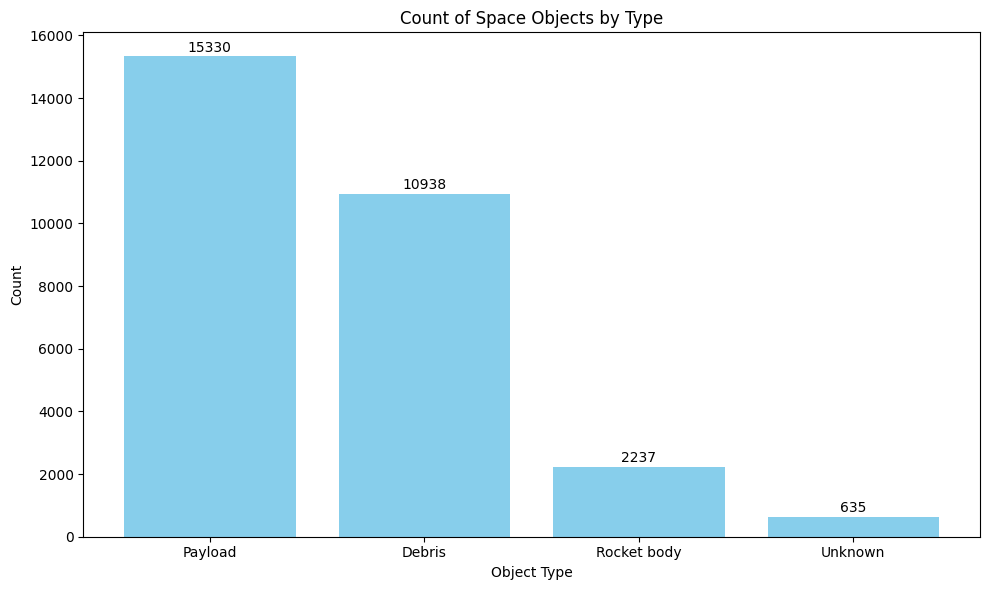

In [113]:
# Get object type counts
object_type_counts = df_sat['object_type'].value_counts()

# Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(object_type_counts.index, object_type_counts.values, color='skyblue')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.title('Count of Space Objects by Type')
plt.xlabel('Object Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Viz: classes of orbits

**Orbit Class Breakdown**


**LEO:** Low Earth Orbit (160–2,000 km altitude).Most common orbit for satellites.
Examples: ISS, Hubble, Starlink, Earth observation satellites.
Characteristics: Short orbital period (~90–120 minutes), fast movement



**HEO:** Highly Elliptical Orbit. Egg-shaped orbits with low perigee and high apogee.
Examples: Molniya orbits (Russian communications), some spy satellites.
Characteristics: Long dwell time over specific regions



**MEO:** Medium Earth Orbit (2,000–35,786 km altitude).
Examples: GPS, GLONASS, Galileo navigation satellites
Characteristics: ~12-hour orbital period, moderate coverage



**GEO:** 877 objects
Geostationary Orbit (35,786 km altitude exactly). Fixed position over equator, moves with Earth's rotation.
Examples: Weather satellites, TV broadcast, communications
Characteristics: 24-hour orbital period, always views same area



**Unknown:** Orbit class cannot be determined. Could be decayed objects awaiting removal from catalog. Tracking anomalies or recently added objects not yet classified.


In [16]:
def classify_orbit(perigee_km, apogee_km, eccentricity):
    """Classify orbit based on perigee, apogee, and eccentricity."""
    if pd.isna(perigee_km) or pd.isna(apogee_km):
        return 'Unknown'
    # GEO band check (both near GEO altitude)
    if (abs(perigee_km - 35786) <= 200) and (abs(apogee_km - 35786) <= 200):
        return 'GEO'
    # HEO check
    if eccentricity > 0.1 and (apogee_km - perigee_km) > 10000:
        return 'HEO'
    # LEO / MEO otherwise
    if perigee_km < 2000:
        return 'LEO'
    if perigee_km < 35786:
        return 'MEO'
    return 'HEO'

df_sat['orbit_class'] = df_sat.apply(lambda row: classify_orbit(row['perigee_alt_km'], row['apogee_alt_km'], row['eccentricity']), axis=1)
df_sat['orbit_class'].value_counts()

,count
orbit_class,
LEO,24872
HEO,2473
MEO,887
GEO,877
Unknown,31


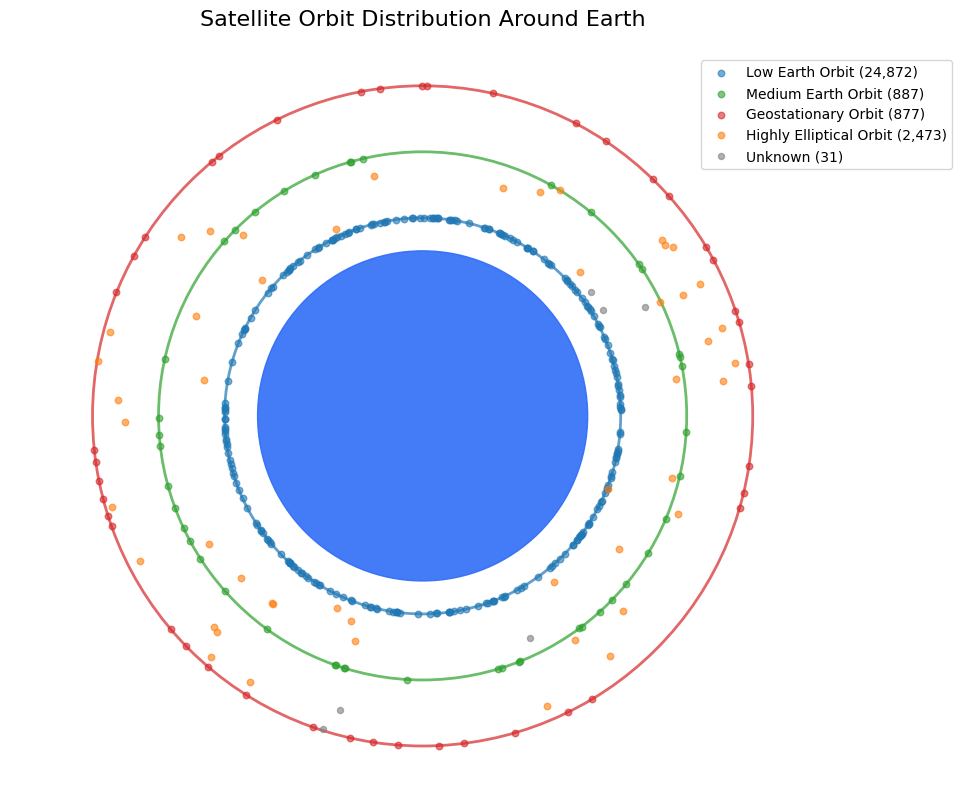

In [40]:
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import numpy as np

orbit_classes = ['LEO', 'HEO', 'MEO', 'GEO', 'Unknown']
counts = [24872, 2473, 887, 877, 31]
percentages = [85.35, 8.49, 3.04, 3.01, 0.11]

# Colors for each orbit class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#7f7f7f']

# Create figure and axis (single subplot) with wider figure
fig, ax = plt.subplots(figsize=(16, 8))

# Draw Earth
earth = Circle((0, 0), 1, color='#2F6DF7', alpha=0.9)
ax.add_patch(earth)

# Orbit radii (normalized)
leo_radius = 1.2
meo_radius = 1.6
geo_radius = 2.0

# Draw orbit rings
leo_ring = Circle((0, 0), leo_radius, fill=False, color=colors[0], linestyle='-', linewidth=2, alpha=0.7)
meo_ring = Circle((0, 0), meo_radius, fill=False, color=colors[2], linestyle='-', linewidth=2, alpha=0.7)
geo_ring = Circle((0, 0), geo_radius, fill=False, color=colors[3], linestyle='-', linewidth=2, alpha=0.7)

ax.add_patch(leo_ring)
ax.add_patch(meo_ring)
ax.add_patch(geo_ring)

# Add scatter points to represent satellites
np.random.seed(42)  # For reproducible random points

# Create legend labels with counts
leo_label = f'Low Earth Orbit ({counts[0]:,})'
meo_label = f'Medium Earth Orbit ({counts[2]:,})'
geo_label = f'Geostationary Orbit ({counts[3]:,})'
heo_label = f'Highly Elliptical Orbit ({counts[1]:,})'
unknown_label = f'Unknown ({counts[4]:,})'

# LEO points
leo_theta = np.random.uniform(0, 2*np.pi, int(counts[0]/100))  # Scaling down for visualization
leo_x = leo_radius * np.cos(leo_theta)
leo_y = leo_radius * np.sin(leo_theta)
ax.scatter(leo_x, leo_y, color=colors[0], s=22, alpha=0.6, label=leo_label)

# MEO points
meo_theta = np.random.uniform(0, 2*np.pi, int(counts[2]/20))  # Scaling down
meo_x = meo_radius * np.cos(meo_theta)
meo_y = meo_radius * np.sin(meo_theta)
ax.scatter(meo_x, meo_y, color=colors[2], s=22, alpha=0.6, label=meo_label)

# GEO points
geo_theta = np.random.uniform(0, 2*np.pi, int(counts[3]/20))  # Scaling down
geo_x = geo_radius * np.cos(geo_theta)
geo_y = geo_radius * np.sin(geo_theta)
ax.scatter(geo_x, geo_y, color=colors[3], s=22, alpha=0.6, label=geo_label)

# HEO points (elliptical orbits)
heo_theta = np.random.uniform(0, 2*np.pi, int(counts[1]/50))  # Scaling down
heo_r = leo_radius + (geo_radius - leo_radius) * np.random.random(len(heo_theta))
heo_x = heo_r * np.cos(heo_theta)
heo_y = heo_r * np.sin(heo_theta)
ax.scatter(heo_x, heo_y, color=colors[1], s=22, alpha=0.6, label=heo_label)

# Unknown points
unknown_theta = np.random.uniform(0, 2*np.pi, int(counts[4]/5))  # Scaling down
unknown_r = leo_radius + (geo_radius - leo_radius) * np.random.random(len(unknown_theta))
unknown_x = unknown_r * np.cos(unknown_theta)
unknown_y = unknown_r * np.sin(unknown_theta)
ax.scatter(unknown_x, unknown_y, color=colors[4], s=19, alpha=0.6, label=unknown_label)

# Set aspect ratio and limits
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)  # Increased x-limits to create more space
ax.set_ylim(-2.2, 2.2)
ax.set_title('Satellite Orbit Distribution Around Earth', fontsize=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0))  # Moved legend outside the plot
ax.axis('off')

plt.tight_layout()
plt.show()

# Assign inclination bands

**Why we calculate it**
- Inclination tells you a satellite’s tilt relative to Earth’s equator.
- Binning it makes orbital planes easy to compare and helps explain traffic corridors (equatorial vs polar vs retrograde planes).
- Conjunction risk is very plane-dependent: crowded planes (e.g., sun-sync near ~98°) see more potential close approaches.

**What it’s useful for**
- Identify which planes are congested.
- Compare operators/constellations by plane.
- Drive heatmaps (altitude shell × inclination band) to show “where the highways are.”

**How to interpret the categories**
- Equatorial (0–30°): GEO and near-equatorial LEO/MEO users; low lat coverage, great for fixed ground links.
- Mid (30–60°): Mixed users; broad coverage without going polar.
- Polar/Sun-sync (60–90°): Earth-observation heavy.
- Retrograde (>90°): Orbits going opposite Earth rotation; rarer, fuel-expensive; can cross other traffic → interesting for risk.

In [30]:
def inclination_band(deg):
    if pd.isna(deg): return "Unknown"
    if deg < 30:     return "Equatorial (0–30°)"
    if deg < 60:     return "Mid (30–60°)"
    if deg <= 90:   return "Polar/Sun-sync (60–90°)"
    return "Retrograde (>90°)"

df_sat["inclination_band"] = df_sat["inclination_els"].apply(inclination_band)
df_sat["inclination_band"].value_counts()

,count
inclination_band,
Mid (30–60°),9116
Retrograde (>90°),8609
Polar/Sun-sync (60–90°),8131
Equatorial (0–30°),3284


# Assign Elliptical Class

**Why we calculate it**
- Eccentricity describes how stretched the orbit is.
- Highly elliptical orbits sweep through multiple altitude shells, touching regions that circular LEOs never visit → different risk profile and drag behavior.

**What it’s useful for**
- Separate circular constellations (Starlink/OneWeb, GEO) from transfer/HEO users (GTO, Molniya, Tundra).
- Explain why some bands have transient traffic (HEO perigees pass through then depart).
- Decide which objects belong in a perigee-based shell analysis.

**How to interpret the categories**
- Near-Circular (<0.01): Constellations and GEO; stable altitude → persistent congestion within a shell.
- Elliptical (0.01–0.10): Transfers or specialized missions; moderate shell crossing.
- Highly Elliptical (≥0.10): Big apogee/perigee swings; spend long time near apogee, dip through perigee shells quickly → they touch many shells but don’t dwell there.

In [31]:
def ecc_class(e):
    if pd.isna(e): return "Unknown"
    if e < 0.01:   return "Near-Circular (<0.01)"
    if e < 0.10:   return "Elliptical (0.01–0.10)"
    return "Highly Elliptical (≥0.10)"

df_sat["ecc_class"] = df_sat["eccentricity"].apply(ecc_class)
df_sat["ecc_class"].value_counts()

,count
ecc_class,
Near-Circular (<0.01),22616
Elliptical (0.01–0.10),4266
Highly Elliptical (≥0.10),2258


# Viz: Distribution by Altitude and Inclination

LEO (<2,000 km perigee)

MEO (2,000–35,000 km)

GEO (near 35,786 km ± 200 km)

HEO (eccentric >0.1, apogee > GEO)

/tmp/ipython-input-1066832879.py:31: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



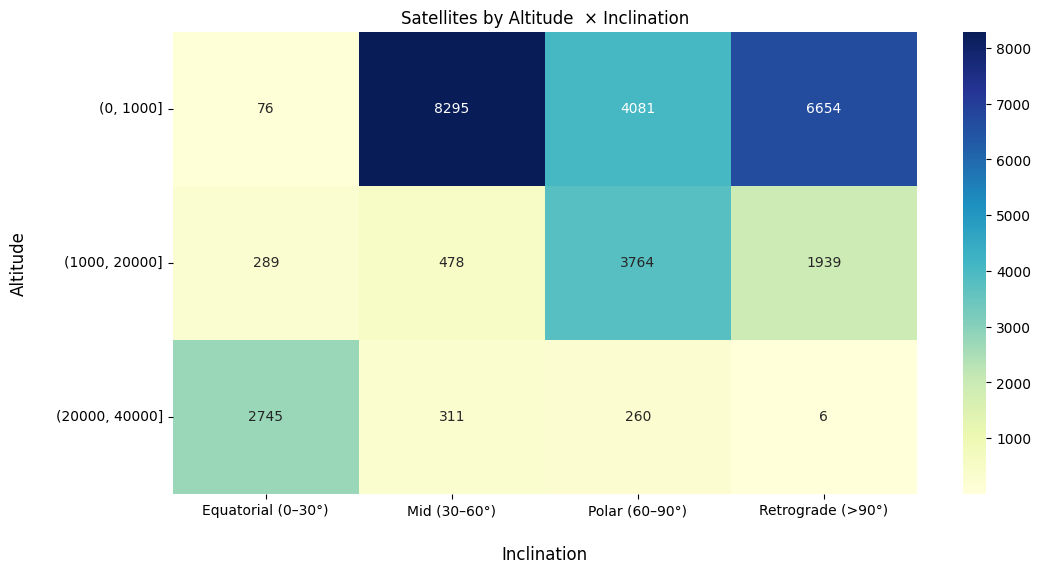

In [134]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Define helper functions ---
def inclination_band(deg):
    if pd.isna(deg): return "Unknown"
    if deg < 30:     return "Equatorial (0–30°)"
    if deg < 60:     return "Mid (30–60°)"
    if deg <= 90:    return "Polar (60–90°)"
    return "Retrograde (>90°)"

def ecc_class(e):
    if pd.isna(e): return "Unknown"
    if e < 0.01:   return "Near-Circular (<0.01)"
    if e < 0.10:   return "Elliptical (0.01–0.10)"
    return "Highly Elliptical (≥0.10)"

# --- Step 2: Assign bands and classes ---
df_sat["inclination_band"] = df_sat["inclination_els"].apply(inclination_band)
df_sat["ecc_class"] = df_sat["eccentricity"].apply(ecc_class)

# --- Step 3: Define altitude bins (same as your heatmap) ---
alt_bins = [0, 1000, 20000, 40000]
alt_labels = ["(0, 1000]", "(1000, 20000]", "(20000, 40000]"]
df_sat["alt_bin"] = pd.cut(df_sat["apogee_alt_km"], bins=alt_bins, labels=alt_labels)

# --- Step 4: Build pivot table ---
pivot = (
    df_sat
    .groupby(["alt_bin", "inclination_band"])
    .size()
    .reset_index(name="count")
    .pivot(index="alt_bin", columns="inclination_band", values="count")
    .fillna(0)
)

# --- Step 5: Plot heatmap ---
plt.figure(figsize=(12,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Satellites by Altitude  × Inclination")
plt.ylabel("Altitude", fontsize=12, labelpad=20)
plt.xlabel("Inclination", fontsize=12, labelpad=20)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()


# Viz: Launch by years and decades

In [42]:
df_sat['launch_year'].value_counts().sort_index()

,count
launch_year,
1958,3
1959,5
1960,11
1961,210
1962,25
...,...
2021,1408
2022,2728
2023,2701


In [43]:
lauch_year_dict = {'1950s': range(1950, 1960),
                   '1960s': range(1960, 1970),
                   '1970s': range(1970, 1980),
                   '1980s': range(1980, 1990),
                   '1990s': range(1990, 2000),
                   '2000s': range(2000, 2010),
                   '2010s': range(2010, 2020),
                   '2020s': range(2020, 2030)}

def classify_launch_year(year):
    if pd.isna(year): return "Unknown"
    for decade, years in lauch_year_dict.items():
        if year in years:
            return decade
    return "Unknown"

df_sat['launch_decade'] = df_sat['launch_year'].apply(classify_launch_year)
df_sat['launch_decade'].value_counts().sort_index()

,count
launch_decade,
1950s,8
1960s,1314
1970s,2655
1980s,2397
1990s,5120
2000s,1780
2010s,2500
2020s,13366


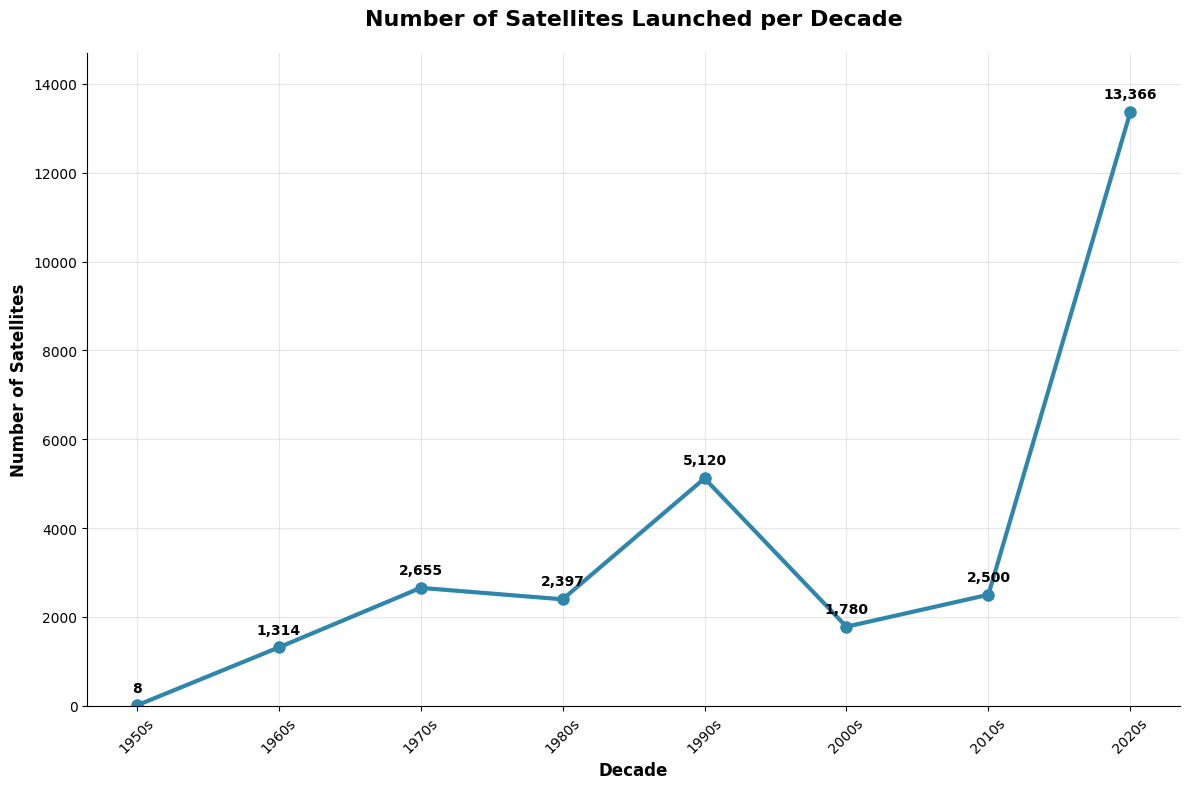

In [44]:
# Create the visualization
plt.figure(figsize=(12, 8))

decades = ['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
satellite_counts = [8,  # 1958-1959
                   df_sat['launch_decade'].value_counts().sort_index().get('1960s', 0),
                   df_sat['launch_decade'].value_counts().sort_index().get('1970s', 0),
                   df_sat['launch_decade'].value_counts().sort_index().get('1980s', 0),
                   df_sat['launch_decade'].value_counts().sort_index().get('1990s', 0),
                   df_sat['launch_decade'].value_counts().sort_index().get('2000s', 0),
                   df_sat['launch_decade'].value_counts().sort_index().get('2010s', 0),
                   df_sat['launch_decade'].value_counts().sort_index().get('2020s', 0)]

# Create line plot
line = plt.plot(decades, satellite_counts, marker='o', linewidth=3, markersize=8, color='#2E86AB')

# Add value annotations on each point
for i, count in enumerate(satellite_counts):
    plt.annotate(f'{count:,}',
                 (decades[i], satellite_counts[i]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center',
                 fontweight='bold')

# Customize the plot
plt.title('Number of Satellites Launched per Decade', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Decade', fontsize=12, fontweight='bold')
plt.ylabel('Number of Satellites', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Set y-axis to start from 0
plt.ylim(0, max(satellite_counts) * 1.1)

# Add some styling
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# Viz: Launch by countries

In [54]:
df_sat['country'].value_counts()

,count
country,
US,14337
CIS,5800
PRC,5379
UK,720
FR,557
...,...
FRIT,1
BELA,1
TMMC,1


In [135]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Get top countries
top_countries = df_sat['country'].value_counts()
top_5 = top_countries.head(5)
others_count = top_countries[5:].sum()

# Create data for the treemap
labels = list(top_5.index) + ['Others']
parents = ['World'] * 6
values = list(top_5.values) + [others_count]

# Calculate percentages
total = sum(values)
percentages = [(v / total) * 100 for v in values]

# Custom labels
custom_labels = [
    f"{country}<br>{percentage:.1f}%"
    for country, percentage in zip(labels, percentages)
]

# Define custom colors (blue, orange, light blue, etc.)
custom_colors =  ["#272D2D", "#094661", "#569AB8", "#9ED0E6", "#9EB0B8"]

# Create treemap with YlGnBu color scheme
fig = px.treemap(
    names=custom_labels,
    parents=parents,
    values=values,
    title='Proportion of Space Objects by Country',
    color=values,  # needed to map values to the colorscale
    color_continuous_scale = custom_colors
)




# Update trace for better formatting
fig.update_traces(
    textinfo='label',
    textfont_size=14,
    marker=dict(cornerradius=5),
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percentParent:.1%}',
)

fig.update_layout(
    coloraxis_showscale=False,  # hides the color scale
    width=1000,
    height=700,
    margin=dict(t=50, l=25, r=25, b=25),
    treemapcolorway=custom_colors
)

fig.show()


# Viz: governmental vs private

In [108]:
name_counts = df_sat[df_sat['country'] == 'US']['name_only'].value_counts()
multiple_names = name_counts[name_counts > 1]

print("Names that appear more than once in the US:")
for name, count in multiple_names.items():
    print(f"{name}: {count} occurrences")

Names that appear more than once in the US:
STARLINK-: 8531 occurrences
DELTA: 1065 occurrences
NOAA: 503 occurrences
OPS: 333 occurrences
THORAD AGENA D DEB: 311 occurrences
ATLAS: 267 occurrences
DMSP: 245 occurrences
IRIDIUM: 240 occurrences
TITAN: 217 occurrences
THOR ABLESTAR DEB: 201 occurrences
FLOCK: 151 occurrences
THORAD DELTA: 150 occurrences
USA: 103 occurrences
KUIPER-: 78 occurrences
NIMBUS: 74 occurrences
LEMUR: 73 occurrences
NAVSTAR: 71 occurrences
FALCON: 58 occurrences
PEGASUS DEB: 58 occurrences
SCOUT G-: 45 occurrences
ELECTRON KICK STAGE R/B: 39 occurrences
IUS R/B(: 36 occurrences
WESTFORD NEEDLES: 36 occurrences
HAWK-: 33 occurrences
GALAXY: 30 occurrences
GOES: 26 occurrences
ATLAS CENTAUR R/B: 25 occurrences
OV: 24 occurrences
SATCOM: 23 occurrences
THOR BURNER: 22 occurrences
SCOUT X-: 21 occurrences
CRRES DEB (CANISTER): 21 occurrences
SCOUT A DEB: 21 occurrences
PEGASUS R/B: 20 occurrences
MIDAS: 20 occurrences
ECHOSTAR: 19 occurrences
EXPLORER: 16 occurren

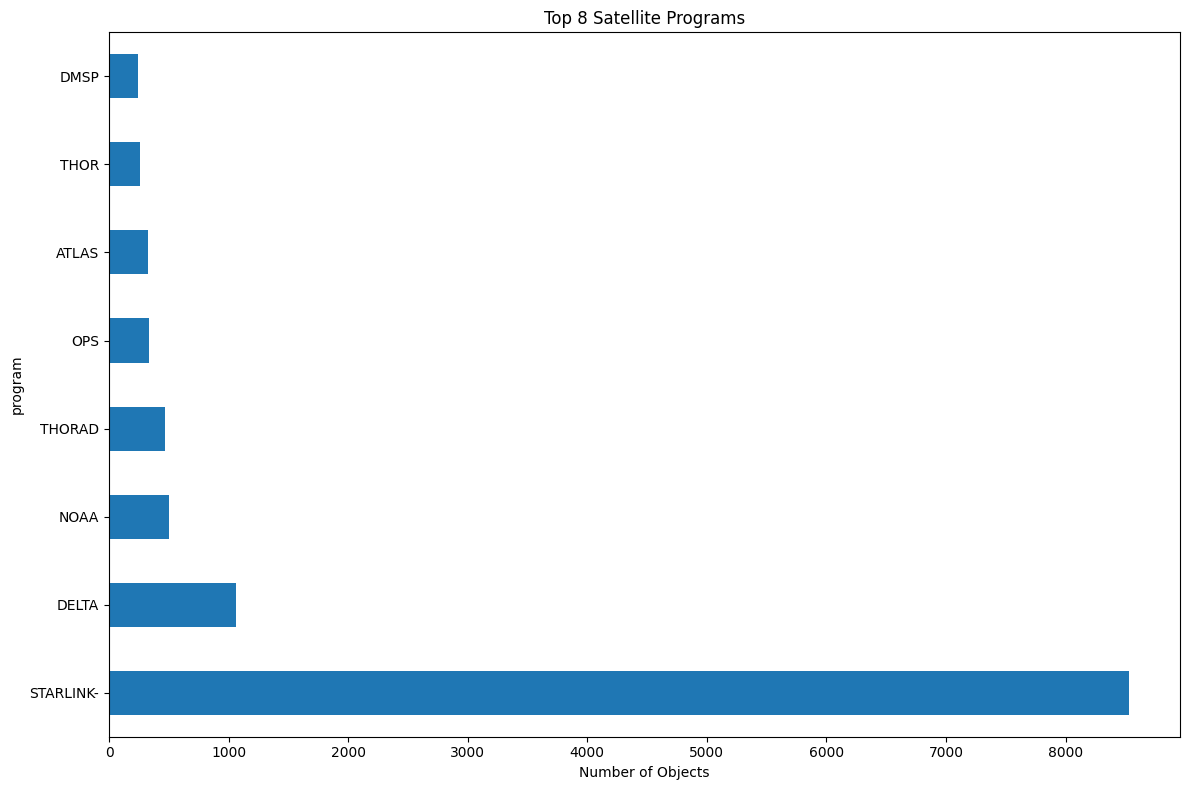

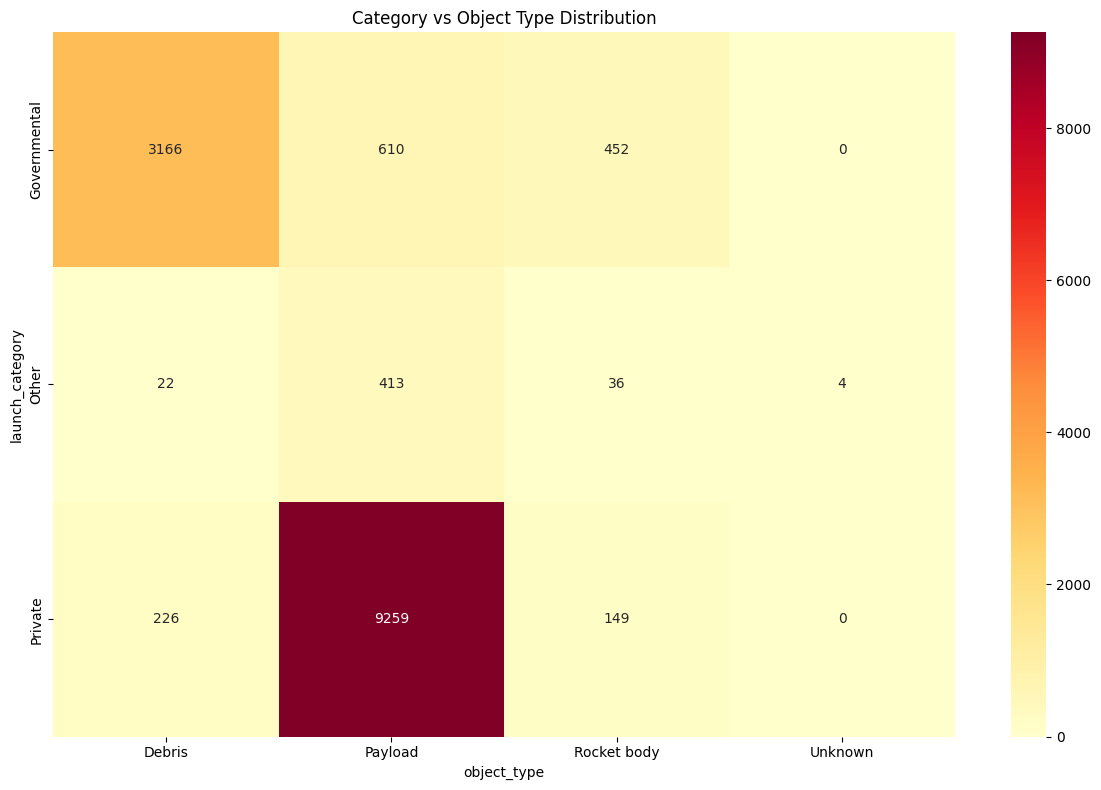

<Figure size 1400x1000 with 0 Axes>

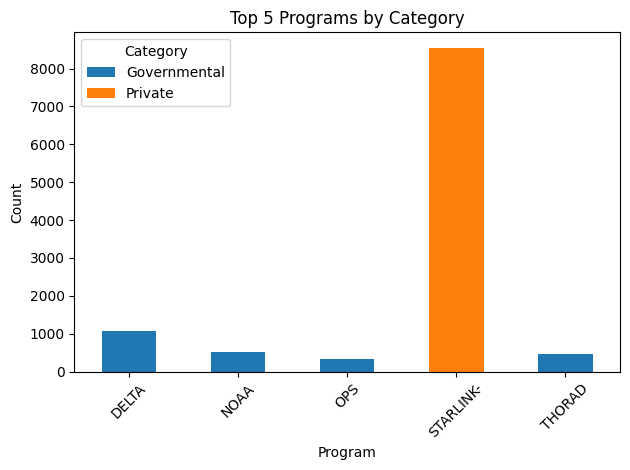

✅ Analysis complete!
📊 Total objects analyzed: 14,337
📁 Detailed results saved to: us_space_objects_detailed_analysis.csv
🖼️  Visualizations saved as separate PNG files


In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter US objects
us_objects = df_sat[df_sat['country'] == 'US'].copy()

# --- REFINED CATEGORIZATION ---
# Let's improve the keyword lists based on common US space objects

governmental_keywords = [
    'NOAA', 'DMSP', 'GPS', 'GOES', 'LANDSAT', 'EOS', 'TDRS',
    'MODIS', 'ICESAT', 'JASON', 'GRACE', 'SUOMI', 'AQUA', 'TERRA',
    'CYGNSS', 'DSCS', 'WGS', 'SBIRS', 'NROL', 'MILSTAR',
    'DEFENSE', 'TITAN', 'MERURY', 'MISTY', 'PAN', 'TRUMPET',
    'VANGUARD', 'EXPLORER', 'BLAZAR', 'TEMPLAR', 'LACROSSE', 'INTRUDER',
    'DSP', 'NAVSTAR', 'WEATHER', 'EARTH', 'CLOUDSAT', 'CALIPSO',
    'SORCE', 'AURA', 'QUIKSCAT', 'SEAWIFS', 'TERRIERS',
    'OPS', 'USA', 'NIMBUS', 'TRANSIT', 'TIROS', 'MIDAS', 'SECOR',
    'LES', 'VELA', 'ATS', 'MMS', 'SMS', 'NTS', 'FLTSATCOM',
    'NNSS', 'LAGEOS', 'TACSAT', 'TIMATION', 'SURCAL', 'AEHF',
    'MUOS', 'LACE', 'HBTSS', 'GRACE-FO', 'HUBBLE', 'OAO',
    'POPACS', 'PUNCH-WFI', 'SYNCOM', 'PAGEOS', 'CALSPHERE',
    'DODECAPOLE', 'PORCUPINE', 'RELAY', 'TEMPSAT', 'COBE',
    'LINCS', 'CRRES', 'GGSE', 'SMDC', 'SSU', 'WILDFIRE', 'DELTA', 'ATLAS', 'TITAN', 'THORAD', 'THOR', 'SCOUT', 'IUS',
    'CENTAUR', 'MINOTAUR', 'SLS', 'ESSA', 'SOLRAD', 'UFO', 'ERS',
    'LDPE', 'WESTFORD', 'JASON', 'MARISAT', 'CYGFM'
]

private_keywords = [
    'STARLINK', 'SPACEX', 'PLANET', 'SKYSAT', 'FLOCK', 'DOVE',
    'LEMUR', 'GLOBALSTAR', 'ORBCOMM', 'KEPLER', 'SWARM',
    'ASTROCAST', 'CAPELLA', 'ICEYE', 'UMBRA', 'BLACKSKY',
    'GHOST', 'HYPERION', 'LIGHTSAIL', 'SKYFI', 'SPIRE', 'TELEOS',
    'IRIDIUM', 'GLOBALSTAR', 'ORBCOMM', 'ECHOSTAR', 'DIRECTV',
    'SIRIUS', 'XM', 'RADIOSAT', 'ASIASTAR', 'GALAXY', 'INTELSAT',
    'EUTELSAT', 'AMC', 'SATMEX', 'THURAYA', 'INMARSAT',
    'KUIPER', 'LEMUR', 'GALAXY', 'SATCOM', 'ECHOSTAR', 'DIRECTV',
    'GLOBAL', 'SKYSAT', 'TELSTAR', 'APRIZESAT', 'LEASAT',
    'INTELSAT', 'CAPELLA', 'XM', 'YAM', 'TOMORROW', 'WORLDVIEW',
    'SPACENET', 'GSTAR', 'SIRIUS', 'COMSTAR', 'VIASAT', 'ORBVIEW',
    'MORELOS', 'WESTAR', 'ANIK', 'GLOBALSTAR', 'PAS', 'HAWK',
    'LYNK', 'GNOMES', 'SPACEMOBILE', 'ECHO', 'RAPTOR', 'BB',
    'CELESTIS', 'SPACEWAY', 'FAISAT', 'PROPCUBE', 'DEMO',
    'MANDRAKE', 'OPTUS', 'JACKAL', 'GENESIS', 'PROMETHEUS',
    'MUSAT', 'PELICAN', 'TRACERS', 'IMPULSE', 'VIGORIDE',
    'STPSAT', 'OMNI', 'TYVAK', 'MACSAT', 'CS', 'AO', 'FALCON','FALCONSAT',
    'SEDNA', 'LIZZIESAT', 'DOVE', 'PEARL', 'SPACEBEE', 'PEGASUS', 'ELECTRON', 'FALCON', 'DRAGON', 'AEROCUBE', 'PICOSAT',
    'CUBESAT', 'BLACKJACK', 'LEGION'
]

# Enhanced categorization function
def categorize_launch(name, object_type):
    if pd.isna(name):
        return 'Other'

    name_str = str(name).upper()

    # Split the name into individual words and filter out debris-related terms
    words = name_str.split()
    filtered_words = [word for word in words if word not in ['R/B', 'DEB', 'ROCKET', 'DEBRIS', 'R/B(', 'DEB(', 'STAGE']]

    # If no meaningful words left after filtering, return Undefined
    if not filtered_words:
        return 'Other'

    # Check each filtered word against governmental keywords
    for word in filtered_words:
        # Clean the word (remove special characters, numbers, etc.)
        clean_word = ''.join(char for char in word if char.isalpha())
        if clean_word and any(keyword == clean_word for keyword in governmental_keywords):
            return 'Governmental'

    # Check each filtered word against private keywords
    for word in filtered_words:
        clean_word = ''.join(char for char in word if char.isalpha())
        if clean_word and any(keyword == clean_word for keyword in private_keywords):
            return 'Private'

    # Special cases for common patterns (exact word matching)
    for word in filtered_words:
        clean_word = ''.join(char for char in word if char.isalpha())
        if clean_word == 'STARLINK':
            return 'Private'
        if clean_word == 'NORAD':
            return 'Governmental'
        if clean_word == 'FALCON' and 'STARLINK' not in name_str:  # Avoid false positives
            return 'Private'

    return 'Other'

# Apply enhanced categorization
us_objects['launch_category'] = us_objects.apply(
    lambda row: categorize_launch(row['satname'], row['object_type']),
    axis=1
)

# --- ANALYSIS ---
category_counts = us_objects['launch_category'].value_counts()
total_objects = len(us_objects)
us_objects['program'] = us_objects['name_only'].apply(
    lambda x: str(x).split()[0] if pd.notna(x) and str(x).strip() != '' else 'Unknown'
)
top_programs = us_objects['program'].value_counts()

# --- SEPARATE VISUALIZATIONS ---

# Bar chart of top programs
plt.figure(figsize=(12, 8))
top_programs.head(8).plot(kind='barh')
plt.title('Top 8 Satellite Programs')
plt.xlabel('Number of Objects')
plt.tight_layout()
plt.savefig('us_top_programs_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Additional visualization: Category by object type (heatmap)
plt.figure(figsize=(12, 8))
category_object_cross = pd.crosstab(us_objects['launch_category'], us_objects['object_type'])
sns.heatmap(category_object_cross, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Category vs Object Type Distribution')
plt.tight_layout()
plt.savefig('us_category_object_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Additional visualization: Top programs by category
plt.figure(figsize=(14, 10))
top_5_programs = top_programs.head(5).index
program_category_data = us_objects[us_objects['program'].isin(top_5_programs)]
program_category_cross = pd.crosstab(program_category_data['program'], program_category_data['launch_category'])
program_category_cross.plot(kind='bar', stacked=True)
plt.title('Top 5 Programs by Category')
plt.xlabel('Program')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.savefig('us_top_programs_by_category.png', dpi=300, bbox_inches='tight')
plt.show()


print(f"✅ Analysis complete!")
print(f"📊 Total objects analyzed: {total_objects:,}")
print(f"📁 Detailed results saved to: {output_file}")
print(f"🖼️  Visualizations saved as separate PNG files")

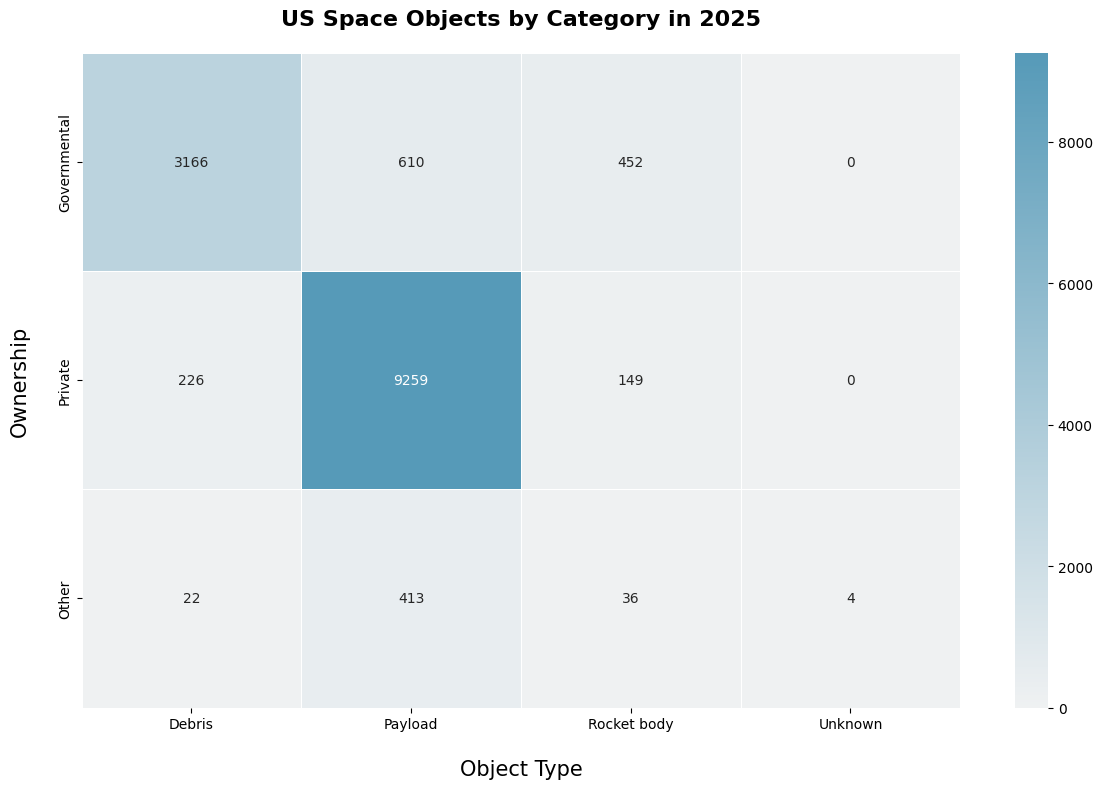

In [140]:
plt.figure(figsize=(12, 8))
category_object_cross = pd.crosstab(us_objects['launch_category'], us_objects['object_type'])

# Reorder index so "Other" comes last
order = ['Governmental', 'Private', 'Other']  # <-- your preferred order
category_object_cross = category_object_cross.reindex(order)

# Create a blue palette based on your color
blue_palette = sns.light_palette("#569AB8", as_cmap=True)

sns.heatmap(
    category_object_cross,
    annot=True,
    fmt='d',
    cmap=blue_palette,
    linewidths=0.5,
    linecolor='white',
)

plt.title('US Space Objects by Category in 2025', fontsize=16, fontweight='bold', pad=20)

# Remove axis labels
plt.xlabel("Object Type", fontsize=15, labelpad=20)
plt.ylabel("Ownership", fontsize=15, labelpad=20)

plt.tight_layout()
plt.show()



<Figure size 2000x1000 with 0 Axes>

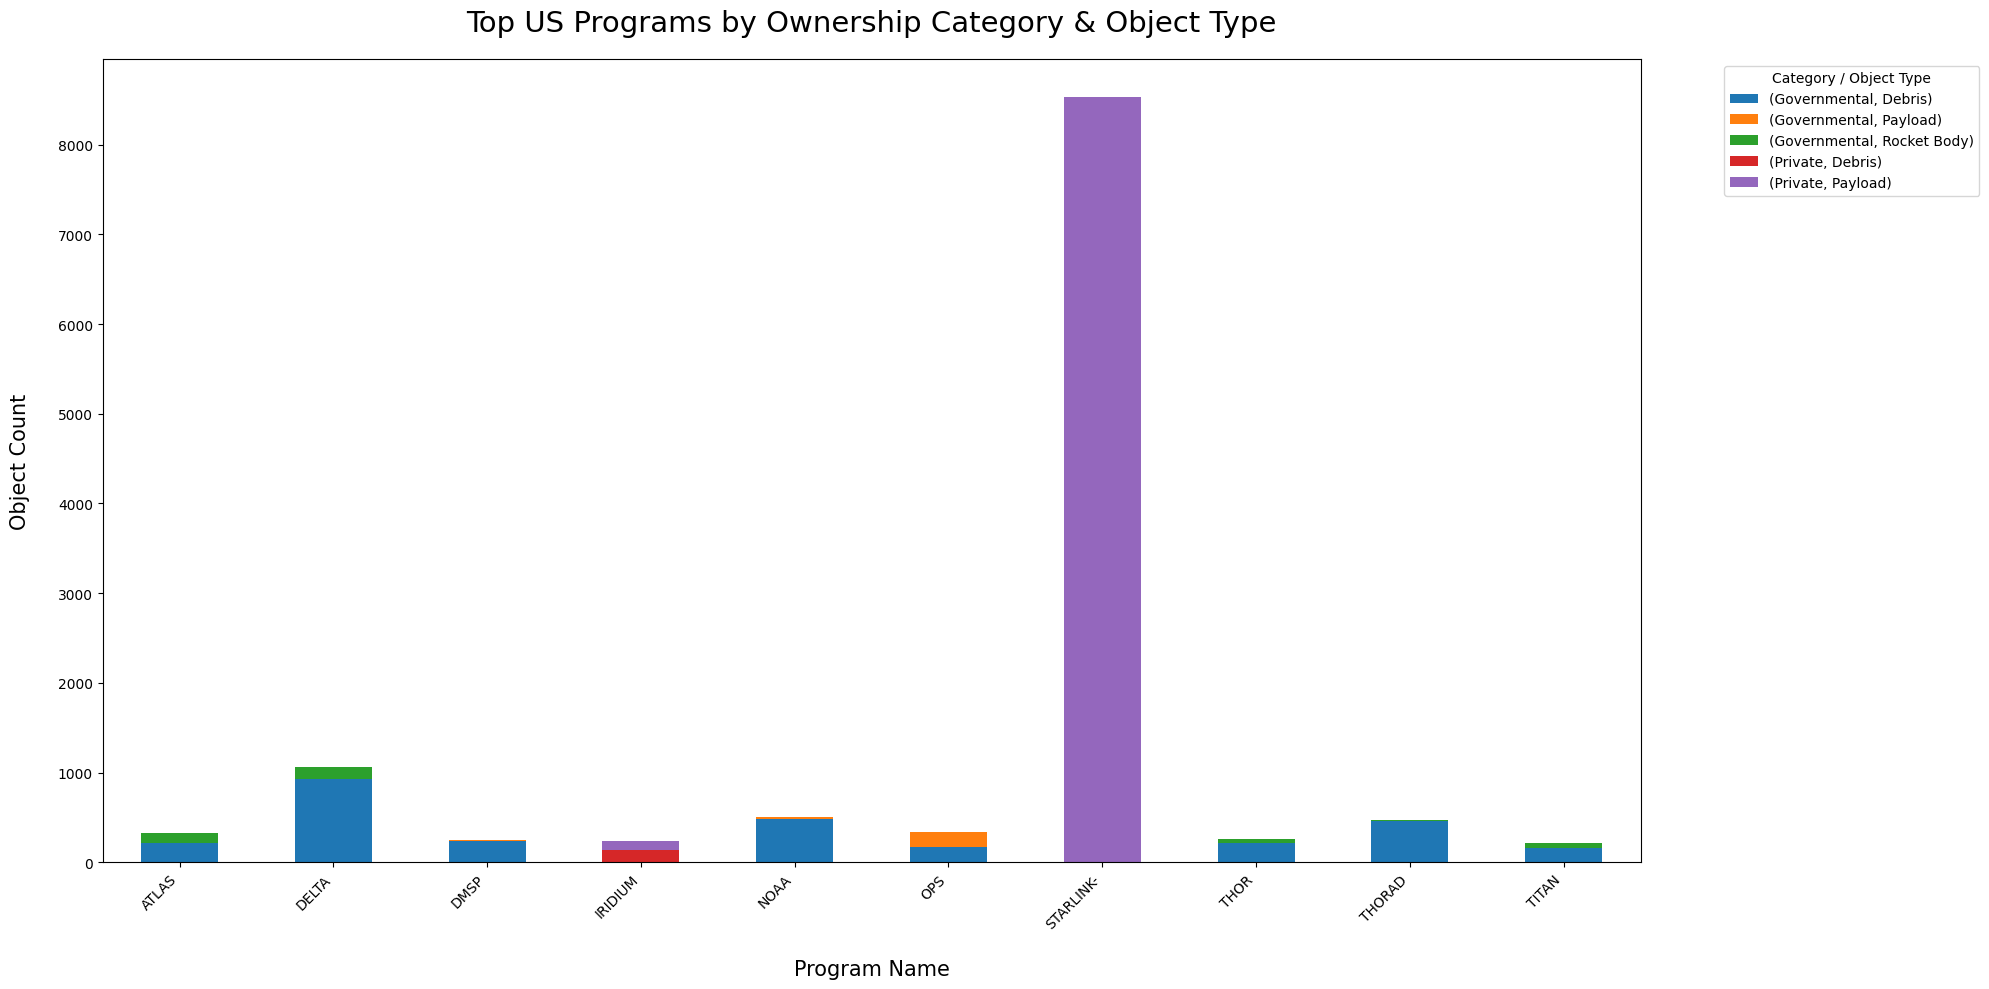

In [143]:
# --- Enhanced: Top programs by category & object type ---
plt.figure(figsize=(20, 10))

# Top 10 programs
top_5_programs = top_programs.head(10).index
program_category_data = us_objects[us_objects['program'].isin(top_5_programs)].copy()

# Normalize object_type into groups
def normalize_object_type(obj_type):
    if pd.isna(obj_type):
        return "Unknown"
    t = str(obj_type).upper()
    if "PAYLOAD" in t:
        return "Payload"
    elif "DEBRIS" in t:
        return "Debris"
    elif "ROCKET" in t or "R/B" in t:
        return "Rocket Body"
    else:
        return "Other"

program_category_data["object_group"] = program_category_data["object_type"].apply(normalize_object_type)

# Build crosstab: Program × (Launch Category + Object Group)
program_category_cross = pd.crosstab(
    program_category_data['program'],
    [program_category_data['launch_category'], program_category_data['object_group']]
)

# Plot stacked bar
program_category_cross.plot(kind='bar', stacked=True, figsize=(20, 10))

plt.title('Top 10 US Programs by Ownership Category & Object Type',fontsize=21, pad = 20)
plt.xlabel('Program Name', fontsize=15, labelpad=20)
plt.ylabel('Object Count', fontsize=15, labelpad=20)
plt.xticks(rotation=45, ha="right")
plt.legend(title='Category / Object Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('us_top_programs_by_category_objecttype.png', dpi=300, bbox_inches='tight')
plt.show()


## Cleaning and Data Wrangling

1. Merge satellite catelog to elset data
2. Keep the latest epoch of data for each satellite in the elset data
3. Remove unnecesary columns
Assign orbit class to each object:
    - LEO (<2,000 km perigee)
    - MEO (2,000–35,000 km)
    - GEO (near 35,786 km ± 200 km)
    - HEO (eccentric >0.1, apogee > GEO)

In [ ]:
# intial check of matching satellite numbers between datasets
sat_list = satcat[['norad_cat_id']].drop_duplicates().rename(columns={'norad_cat_id': 'satNo'})
sat_no_list = df_all[['satNo']].drop_duplicates()
merged = sat_no_list[['satNo']].merge(sat_list, on='satNo', how='outer', indicator=True)
merged['_merge'].value_counts()

_merge
right_only    36125
both          29140
left_only       576
Name: count, dtype: int64

Only keep rows in both datasets

In [ ]:
df_all.head()

,algorithm,apogee,argOfPerigee,bStar,classificationMarking,createdAt,createdBy,eccentricity,source,semiMajorAxis,satNo,revNo,raan,period,perigee,origNetwork,meanMotionDot,meanMotionDDot,meanMotion,meanAnomaly,inclination,idOnOrbit,idElset,epoch,epoch_date
0,SGP4,10202.213,259.3559,0.000943,U,2025-01-02 00:05:10.959000+00:00,system.ob-ingest,0.184317,18th SPCS,8614.424,5,38543,156.6751,132.617,7026.636,OPS1,0.000008,0.0,10.858339,79.5230,34.2561,5,<NA>,2025-01-01 01:49:54.598368+00:00,2025-01-01
1,SGP4,10202.217,262.2564,0.000996,U,2025-01-02 06:05:08.465000+00:00,system.ob-ingest,0.184319,18th SPCS,8614.417,5,38550,154.6883,132.617,7026.617,OPS1,0.000008,0.0,10.858352,76.5981,34.2564,5,<NA>,2025-01-01 17:17:08.960640+00:00,2025-01-01
2,SGP4,9286.717,275.2650,0.001633,U,2025-01-01 23:05:08.691000+00:00,system.ob-ingest,0.145307,18th SPCS,8108.493,11,81389,294.6285,121.107,6930.269,OPS1,0.000031,0.0,11.890292,68.4325,32.8795,11,<NA>,2025-01-01 19:06:31.800960+00:00,2025-01-01
3,SGP4,9673.868,173.3927,0.000874,U,2025-01-01 23:05:08.697000+00:00,system.ob-ingest,0.165118,18th SPCS,8302.909,12,71282,296.3941,125.489,6931.950,OPS1,0.000015,0.0,11.475123,189.1611,32.9011,12,<NA>,2025-01-01 19:47:07.123200+00:00,2025-01-01
4,SGP4,10594.496,34.2347,0.000585,U,2025-01-02 00:05:10.967000+00:00,system.ob-ingest,0.202279,18th SPCS,8812.011,16,63302,43.3806,137.206,7029.527,OPS1,0.000004,0.0,10.495187,337.3462,34.2656,16,<NA>,2025-01-01 06:18:04.587840+00:00,2025-01-01


In [ ]:
satcat.head()

,intldes,norad_cat_id,object_type,satname,country,launch,site,decay,period,inclination,apogee,perigee,comment,commentcode,rcsvalue,rcs_size,file,launch_year,launch_num,launch_piece,current,object_name,object_id,object_number
0,1957-001A,1,ROCKET BODY,SL-1 R/B,CIS,1957-10-04,TTMTR,1957-12-01,96.19,65.10,938.0,214.0,NaN,4.0,0,LARGE,1,1957,1,A,Y,SL-1 R/B,1957-001A,1
1,1957-001B,2,PAYLOAD,SPUTNIK 1,CIS,1957-10-04,TTMTR,1958-01-03,96.10,65.00,1080.0,64.0,NaN,NaN,0,NaN,7179,1957,1,B,Y,SPUTNIK 1,1957-001B,2
2,1957-002A,3,PAYLOAD,SPUTNIK 2,CIS,1957-11-03,TTMTR,1958-04-14,103.74,65.33,1659.0,211.0,NaN,NaN,0,SMALL,9221,1957,2,A,Y,SPUTNIK 2,1957-002A,3
3,1958-001A,4,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,NaN,NaN,0,NaN,1,1958,1,A,Y,EXPLORER 1,1958-001A,4
4,1958-002B,5,PAYLOAD,VANGUARD 1,US,1958-03-17,AFETR,NaN,132.61,34.26,3823.0,649.0,NaN,NaN,0,SMALL,9235,1958,2,B,Y,VANGUARD 1,1958-002B,5


In [ ]:
merged = df_all.merge(satcat, left_on='satNo', right_on='norad_cat_id', how='inner', suffixes=('_els', '_sat'))
merged.shape

(9510016, 49)

In [ ]:
# check differences in orbital parameters between datasets
stats_check = merged[['apogee_els', 'apogee_sat', 'perigee_els', 'perigee_sat', 'period_els', 'period_sat']].copy()
stats_check['apogee_diff'] = stats_check['apogee_els'] - stats_check['apogee_sat']
stats_check['perigee_diff'] = stats_check['perigee_els'] - stats_check['perigee_sat']
stats_check['period_diff'] = stats_check['period_els'] - stats_check['period_sat']
stats_check.head(10)

,apogee_els,apogee_sat,perigee_els,perigee_sat,period_els,period_sat,apogee_diff,perigee_diff,period_diff
0,10202.213,3823.0,7026.636,649.0,132.617,132.61,6379.213,6377.636,0.007
1,10202.217,3823.0,7026.617,649.0,132.617,132.61,6379.217,6377.617,0.007
2,9286.717,2900.0,6930.269,552.0,121.107,121.01,6386.717,6378.269,0.097
3,9673.868,3290.0,6931.950,556.0,125.489,125.45,6383.868,6375.950,0.039
4,10594.496,4217.0,7029.527,650.0,137.206,137.20,6377.496,6379.527,0.006
5,9597.348,3213.0,6886.204,509.0,124.105,124.04,6384.348,6377.204,0.065
6,9597.322,3213.0,6886.212,509.0,124.105,124.04,6384.322,6377.212,0.065
7,6972.199,565.0,6832.162,443.0,95.113,94.70,6407.199,6389.162,0.413
8,6972.024,565.0,6832.128,443.0,95.111,94.70,6407.024,6389.128,0.411
9,7031.000,651.0,7000.123,620.0,97.466,97.42,6380.000,6380.123,0.046


In [ ]:
stats_check.describe()

,apogee_els,apogee_sat,perigee_els,perigee_sat,period_els,period_sat,apogee_diff,perigee_diff,period_diff
count,9.400128e+06,9.509384e+06,9.400128e+06,9.509384e+06,9.242801e+06,9.509384e+06,9.399509e+06,9.399509e+06,9.242182e+06
mean,1.107926e+04,4.738493e+03,9.857155e+03,3.516206e+03,2.031563e+02,2.247050e+02,6.395982e+03,6.382509e+03,2.615757e-01
std,1.126123e+04,1.132044e+04,9.324520e+03,9.394080e+03,3.499089e+02,3.841806e+02,4.388793e+02,2.815223e+02,2.717809e+01
min,6.495761e+03,9.500000e+01,4.901396e+03,0.000000e+00,8.680700e+01,8.630000e+01,-2.442230e+05,-1.738973e+05,-2.896944e+04
25%,6.918712e+03,5.380000e+02,6.875817e+03,4.900000e+02,9.534900e+01,9.510000e+01,6.377797e+03,6.377737e+03,-2.000000e-03
50%,7.078346e+03,6.960000e+02,6.959703e+03,5.770000e+02,9.780200e+01,9.805000e+01,6.378457e+03,6.378480e+03,4.000000e-03
75%,7.557430e+03,1.183000e+03,7.271018e+03,8.970000e+02,1.053160e+02,1.065900e+02,6.382093e+03,6.381032e+03,5.100000e-02
max,6.195078e+05,6.385230e+05,3.072422e+05,3.149730e+05,5.180281e+04,5.569945e+04,7.279530e+04,1.572103e+05,1.605252e+04


Most differences in apogee and perigee appear to be due to the Earth's radius being included in the elset dataset vs not included in the satellite catelog. I will account for this and create new apogee and perigee columns.

In [ ]:
# keep only the latest epoch for each satellite
df_latest = (merged.sort_values("epoch")
                      .groupby("satNo")
                      .tail(1))
df_latest.shape

(29140, 49)

In [ ]:
df_latest.head()

,algorithm,apogee_els,argOfPerigee,bStar,classificationMarking,createdAt,createdBy,eccentricity,source,semiMajorAxis,satNo,revNo,raan,period_els,perigee_els,origNetwork,meanMotionDot,meanMotionDDot,meanMotion,meanAnomaly,inclination_els,idOnOrbit,idElset,epoch,epoch_date,intldes,norad_cat_id,object_type,satname,country,launch,site,decay,period_sat,inclination_sat,apogee_sat,perigee_sat,comment,commentcode,rcsvalue,rcs_size,file,launch_year,launch_num,launch_piece,current,object_name,object_id,object_number
31636,SGP4,6713.220,158.0519,0.071972,U,2025-01-01 16:05:13.461000+00:00,system.ob-ingest,0.002807,18th SPCS,6694.428,60773,2104,332.9594,90.851,6675.636,OPS1,0.123356,0.274000,15.850119,202.1971,88.9702,60773,<NA>,2025-01-01 05:40:21.204192+00:00,2025-01-01,2024-140EY,60773,DEBRIS,CZ-6A DEB,PRC,2024-08-06,TSC,2025-01-06,90.85,88.97,335.0,298.0,NaN,NaN,0,SMALL,9003,2024,140,EY,Y,CZ-6A DEB,2024-140EY,60773
25359,SGP4,6572.676,274.5234,0.000266,U,2025-01-02 00:05:13.604000+00:00,system.ob-ingest,0.000283,18th SPCS,6570.814,56091,10246,70.4408,88.346,6568.951,OPS1,0.011464,0.000002,16.299491,131.9252,96.3242,56091,<NA>,2025-01-01 06:26:51.037728+00:00,2025-01-01,2023-045A,56091,PAYLOAD,COSMOS 2568,CIS,2023-03-29,PKMTR,2025-01-03,87.19,96.33,141.0,130.0,NaN,NaN,0,LARGE,9000,2023,45,A,Y,COSMOS 2568,2023-045A,56091
11943,SGP4,6689.589,333.9987,0.015160,U,2025-01-01 15:05:11.434000+00:00,system.ob-ingest,0.002177,18th SPCS,6675.056,33989,84795,57.0027,90.457,6660.522,OPS1,0.041511,0.022317,15.919171,26.0151,73.9751,33989,<NA>,2025-01-01 09:48:54.658944+00:00,2025-01-01,1993-036FY,33989,DEBRIS,COSMOS 2251 DEB,CIS,1993-06-16,PKMTR,2025-01-06,90.46,73.98,311.0,282.0,NaN,NaN,0,SMALL,9003,1993,36,FY,Y,COSMOS 2251 DEB,1993-036FY,33989
22797,SGP4,6525.653,212.6438,0.000296,U,2025-01-01 12:05:11.766000+00:00,system.ob-ingest,0.000228,18th SPCS,6524.163,53714,12937,346.7018,87.407,6522.674,OPS1,0.158177,0.000013,16.474625,285.8411,53.2010,53714,<NA>,2025-01-01 10:32:12.338880+00:00,2025-01-01,2022-107Q,53714,PAYLOAD,STARLINK-4688,US,2022-09-05,AFETR,2025-01-01,87.41,53.20,148.0,145.0,NaN,NaN,0,LARGE,9000,2022,107,Q,Y,STARLINK-4688,2022-107Q,53714
13338,SGP4,7100.459,59.2819,0.018898,U,2025-01-01 23:05:11.521000+00:00,system.ob-ingest,0.001498,18th SPCS,7089.840,38275,74271,262.7376,99.018,7079.222,OPS1,0.000812,0.000000,14.542801,300.9849,81.1576,38275,<NA>,2025-01-01 10:44:23.122176+00:00,2025-01-01,1979-095BV,38275,DEBRIS,METEOR 2-5 DEB,CIS,1979-10-31,PKMTR,NaN,99.02,81.16,722.0,701.0,NaN,1.0,0,SMALL,9029,1979,95,BV,Y,METEOR 2-5 DEB,1979-095BV,38275


In [ ]:
# identify missing values in the latest dataset
missing_values = df_latest.isna().sum().reset_index().rename(columns={0: 'n_missing'}).sort_values(by='n_missing', ascending=False)
missing_values = missing_values[missing_values['n_missing'] > 0]
missing_values

,index,n_missing
22,idElset,29140
37,comment,29134
38,commentcode,28865
32,decay,27942
40,rcs_size,412
0,algorithm,31
11,revNo,31
1,apogee_els,31
13,period_els,31
14,perigee_els,31


In [ ]:
# remove unnecesary columns
df_sat = df_latest.drop(columns=['idElset','comment', 'commentcode', 'createdBy', 'source', 'origNetwork', 'algorithm', 'classificationMarking', 'current'])
df_sat.head()

,apogee_els,argOfPerigee,bStar,createdAt,eccentricity,semiMajorAxis,satNo,revNo,raan,period_els,perigee_els,meanMotionDot,meanMotionDDot,meanMotion,meanAnomaly,inclination_els,idOnOrbit,epoch,epoch_date,intldes,norad_cat_id,object_type,satname,country,launch,site,decay,period_sat,inclination_sat,apogee_sat,perigee_sat,rcsvalue,rcs_size,file,launch_year,launch_num,launch_piece,object_name,object_id,object_number
31636,6713.220,158.0519,0.071972,2025-01-01 16:05:13.461000+00:00,0.002807,6694.428,60773,2104,332.9594,90.851,6675.636,0.123356,0.274000,15.850119,202.1971,88.9702,60773,2025-01-01 05:40:21.204192+00:00,2025-01-01,2024-140EY,60773,DEBRIS,CZ-6A DEB,PRC,2024-08-06,TSC,2025-01-06,90.85,88.97,335.0,298.0,0,SMALL,9003,2024,140,EY,CZ-6A DEB,2024-140EY,60773
25359,6572.676,274.5234,0.000266,2025-01-02 00:05:13.604000+00:00,0.000283,6570.814,56091,10246,70.4408,88.346,6568.951,0.011464,0.000002,16.299491,131.9252,96.3242,56091,2025-01-01 06:26:51.037728+00:00,2025-01-01,2023-045A,56091,PAYLOAD,COSMOS 2568,CIS,2023-03-29,PKMTR,2025-01-03,87.19,96.33,141.0,130.0,0,LARGE,9000,2023,45,A,COSMOS 2568,2023-045A,56091
11943,6689.589,333.9987,0.015160,2025-01-01 15:05:11.434000+00:00,0.002177,6675.056,33989,84795,57.0027,90.457,6660.522,0.041511,0.022317,15.919171,26.0151,73.9751,33989,2025-01-01 09:48:54.658944+00:00,2025-01-01,1993-036FY,33989,DEBRIS,COSMOS 2251 DEB,CIS,1993-06-16,PKMTR,2025-01-06,90.46,73.98,311.0,282.0,0,SMALL,9003,1993,36,FY,COSMOS 2251 DEB,1993-036FY,33989
22797,6525.653,212.6438,0.000296,2025-01-01 12:05:11.766000+00:00,0.000228,6524.163,53714,12937,346.7018,87.407,6522.674,0.158177,0.000013,16.474625,285.8411,53.2010,53714,2025-01-01 10:32:12.338880+00:00,2025-01-01,2022-107Q,53714,PAYLOAD,STARLINK-4688,US,2022-09-05,AFETR,2025-01-01,87.41,53.20,148.0,145.0,0,LARGE,9000,2022,107,Q,STARLINK-4688,2022-107Q,53714
13338,7100.459,59.2819,0.018898,2025-01-01 23:05:11.521000+00:00,0.001498,7089.840,38275,74271,262.7376,99.018,7079.222,0.000812,0.000000,14.542801,300.9849,81.1576,38275,2025-01-01 10:44:23.122176+00:00,2025-01-01,1979-095BV,38275,DEBRIS,METEOR 2-5 DEB,CIS,1979-10-31,PKMTR,NaN,99.02,81.16,722.0,701.0,0,SMALL,9029,1979,95,BV,METEOR 2-5 DEB,1979-095BV,38275


In [ ]:
df_sat['country'].value_counts().sort_values(ascending=False)

country
US      14337
CIS      5800
PRC      5379
UK        720
FR        557
        ...  
BELA        1
TMMC        1
SVN         1
LAOS        1
BOL         1
Name: count, Length: 104, dtype: int64

### Assign Orbit Classes to Each Object

1. Prep data by creating new perigee and apogee columns. Need to account for Earth's radius already being included in the elset apogee and perigee columns.
2. Flag rows with vast differences in perigee and apogee across datasets after account for Earth's radius.
3. Create new categorical column with the orbit class for each object.

In [ ]:
EARTH_RADIUS = 6378.137  # km (WGS84 equatorial radius)
df_sat["perigee_alt_km"] = df_sat["perigee_els"] - EARTH_RADIUS
df_sat["apogee_alt_km"]  = df_sat["apogee_els"]  - EARTH_RADIUS


In [ ]:
df_check = df_sat[['satNo', 'perigee_sat', 'apogee_sat', 'perigee_alt_km', 'apogee_alt_km']].copy()
df_check['apogee_diff'] = df_check['apogee_sat'] - df_check['apogee_alt_km']
df_check['perigee_diff'] = df_check['perigee_sat'] - df_check['perigee_alt_km']
df_check[['apogee_diff', 'perigee_diff']].describe()

,apogee_diff,perigee_diff
count,29103.000000,29103.000000
mean,-1.505660,3.501992
std,248.867713,623.350550
min,-13836.053000,-18832.942000
25%,-1.051000,-0.961000
50%,-0.113000,-0.172000
75%,0.405000,0.457000
max,31497.941000,102451.756000


In [ ]:
df_check[df_check['apogee_diff'].abs() > 100].sort_values(by='apogee_diff', ascending=False)

,satNo,perigee_sat,apogee_sat,perigee_alt_km,apogee_alt_km,apogee_diff,perigee_diff
8791844,59228,314973.0,638523.0,300864.064,607025.059,31497.941,14108.936
9424361,39459,78179.0,460746.0,87904.856,443233.507,17512.493,-9725.856
9119261,43435,123504.0,335955.0,117918.953,333626.197,2328.803,5585.047
9361498,837,49238.0,156751.0,50454.034,155541.132,1209.868,-1216.034
9311024,674,50536.0,167187.0,51631.031,166116.286,1070.714,-1095.031
...,...,...,...,...,...,...,...
9406687,63158,118.0,2485.0,108.588,8626.123,-6141.123,9.412
8755973,37755,58963.0,296547.0,77795.942,303550.707,-7003.707,-18832.942
8760921,60058,148603.0,437008.0,144033.018,444017.202,-7009.202,4569.982
7773795,57770,227890.0,298108.0,125438.244,308387.709,-10279.709,102451.756


In [ ]:
apogee_mismatch = df_check[df_check['apogee_diff'].abs() > 200]['satNo']
perigee_mismatch = df_check[df_check['perigee_diff'].abs() > 200]['satNo']
df_sat['apogee_mismatch'] = df_sat['satNo'].isin(apogee_mismatch)
df_sat['perigee_mismatch'] = df_sat['satNo'].isin(perigee_mismatch)
print('Objects with apogee mismatch between elset data and satellite catalog: ',  df_sat['apogee_mismatch'].sum())
print('Objects with perigee mismatch between elset data and satellite catalog: ', df_sat['perigee_mismatch'].sum())

Objects with apogee mismatch between elset data and satellite catalog:  80
Objects with perigee mismatch between elset data and satellite catalog:  47


In [ ]:
# drop duplicate columns
df_sat = df_sat.drop(columns=['apogee_sat', 'perigee_sat', 'apogee_els', 'perigee_els', 'period_sat'])

In [ ]:
df_sat['perigee_alt_km'].describe()

count     29109.000000
mean       3311.684659
std        9232.091124
min        -218.163000
25%         494.306000
50%         637.345000
75%         924.623000
max      300864.064000
Name: perigee_alt_km, dtype: float64

In [ ]:
df_sat[df_sat['perigee_alt_km'] > 35786]

,argOfPerigee,bStar,createdAt,eccentricity,semiMajorAxis,satNo,revNo,raan,period_els,meanMotionDot,meanMotionDDot,meanMotion,meanAnomaly,inclination_els,idOnOrbit,epoch,epoch_date,intldes,norad_cat_id,object_type,satname,country,launch,site,decay,inclination_sat,rcsvalue,rcs_size,file,launch_year,launch_num,launch_piece,object_name,object_id,object_number,perigee_alt_km,apogee_alt_km,apogee_mismatch,perigee_mismatch
6817454,77.3100,0.0,2025-06-01 23:07:57.174000+00:00,0.478972,118085.757,1459,4724,10.7885,6730.634,-1.638000e-05,0.0,0.213947,359.1419,41.1385,1459,2025-06-05 21:51:56.298528+00:00,2025-06-05,1965-058B,1459,PAYLOAD,OPS 6564 (VELA 6),US,1965-07-20,AFETR,NaN,41.15,0,NaN,9204,1965,58,B,OPS 6564 (VELA 6),1965-058B,1459,55147.861,168267.379,False,False
7263010,214.1037,0.0,2025-06-12 23:07:45.793000+00:00,0.561497,115743.495,692,4975,44.9241,6531.375,-1.215000e-05,0.0,0.220474,359.8474,26.4185,692,2025-06-16 23:56:12.566688+00:00,2025-06-16,1963-039C,692,PAYLOAD,VELA 1,US,1963-10-17,AFETR,NaN,27.98,0,LARGE,9230,1963,39,C,VELA 1,1963-039C,692,44375.744,174354.972,True,True
7567223,106.2819,0.0,2025-06-19 15:07:54.170000+00:00,0.465431,118552.398,2766,4546,12.5797,6770.570,-1.518000e-05,0.0,0.212685,358.6899,34.3846,2766,2025-06-23 20:20:07.323936+00:00,2025-06-23,1967-040B,2766,PAYLOAD,OPS 6679 (VELA 8),US,1967-04-28,AFETR,NaN,34.38,0,NaN,9202,1967,40,B,OPS 6679 (VELA 8),1967-040B,2766,56996.276,167352.245,False,False
7773795,294.0371,0.0,2025-07-01 19:08:02.658000+00:00,0.409666,223291.114,57770,43,3.0372,17501.162,-3.581000e-05,0.0,0.082280,359.8283,33.9343,57770,2025-06-27 12:38:30.285888+00:00,2025-06-27,2023-098C,57770,PAYLOAD,CH 3 PROPULSION MODULE,IND,2023-07-14,SRI,NaN,34.48,0,NaN,9237,2023,98,C,CH 3 PROPULSION MODULE,2023-098C,57770,125438.244,308387.709,True,True
8091510,222.1863,0.0,2025-07-07 23:07:54.905000+00:00,0.005719,43628.664,43513,2507,177.4520,1511.533,-1.010000e-06,0.0,0.952675,137.0417,1.0584,43513,2025-07-04 18:45:37.102752+00:00,2025-07-04,1969-013R,43513,DEBRIS,TITAN 3C TRANSTAGE DEB,US,1969-02-09,AFETR,NaN,1.07,0,NaN,9240,1969,13,R,TITAN 3C TRANSTAGE DEB,1969-013R,43513,37000.997,37500.057,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9492270,177.1928,0.0,2025-08-03 18:07:56.769000+00:00,0.001099,42506.467,32293,1223,79.7541,1453.591,-1.200000e-06,0.0,0.990650,177.0523,3.9314,32293,2025-08-03 12:46:16.166784+00:00,2025-08-03,2007-056A,32293,PAYLOAD,STAR ONE C1,BRAZ,2007-11-14,FRGUI,NaN,4.00,0,LARGE,9240,2007,56,A,STAR ONE C1,2007-056A,32293,36081.594,36175.066,False,False
9490244,40.8075,0.0,2025-08-04 04:07:52.337000+00:00,0.000138,42246.557,25897,9481,15.0076,1440.279,7.500000e-07,0.0,0.999806,316.6255,13.4376,25897,2025-08-03 12:46:38.866656+00:00,2025-08-03,1999-047B,25897,PAYLOAD,YAMAL 102,CIS,1999-09-06,TTMTR,NaN,13.46,0,LARGE,9240,1999,47,B,YAMAL 102,1999-047B,25897,35862.607,35874.233,False,False
9486229,30.7062,0.0,2025-08-03 18:07:51.067000+00:00,0.007788,42951.329,9803,2155,287.0537,1476.470,-8.300000e-07,0.0,0.975299,132.0331,5.5411,9803,2025-08-03 12:50:38.248224+00:00,2025-08-03,1977-007A,9803,PAYLOAD,OPS 3151,US,1977-02-06,AFETR,NaN,5.48,0,NaN,9237,1977,7,A,OPS 3151,1977-007A,9803,36238.704,36907.679,False,False
9485398,350.5812,0.0,2025-08-03 18:07:50.610000+00:00,0.002015,42766.836,5204,20311,292.2550,1466.967,-1.000000e-06,0.0,0.981617,167.5107,0.6051,5204,2025-08-03 12:50:38.248224+00:00,2025-08-03,1971-039A,5204,PAYLOAD,OPS 3811,US,1971-05-05,AFETR,NaN,0.55,0,NaN,9240,1971,39,A,OPS 3811,1971-039A,5204,36302.541,36474.857,False,False


In [ ]:
def classify_orbit(perigee_km, apogee_km, eccentricity):
    """Classify orbit based on perigee, apogee, and eccentricity."""
    if pd.isna(perigee_km) or pd.isna(apogee_km):
        return 'Unknown'
    # GEO band check (both near GEO altitude)
    if (abs(perigee_km - 35786) <= 200) and (abs(apogee_km - 35786) <= 200):
        return 'GEO'
    # HEO check
    if eccentricity > 0.1 and (apogee_km - perigee_km) > 10000:
        return 'HEO'
    # LEO / MEO otherwise
    if perigee_km < 2000:
        return 'LEO'
    if perigee_km < 35786:
        return 'MEO'
    return 'HEO'

df_sat['orbit_class'] = df_sat.apply(lambda row: classify_orbit(row['perigee_alt_km'], row['apogee_alt_km'], row['eccentricity']), axis=1)
df_sat['orbit_class'].value_counts()

orbit_class
LEO        24872
HEO         2473
MEO          887
GEO          877
Unknown       31
Name: count, dtype: int64

In [ ]:
df_sat['orbit_class'].value_counts(normalize=True) * 100

orbit_class
LEO        85.353466
HEO         8.486616
MEO         3.043926
GEO         3.009609
Unknown     0.106383
Name: proportion, dtype: float64

### Clean object types and look at relationship with orbit classes

In [ ]:
df_sat['object_type'].value_counts()

object_type
PAYLOAD        15330
DEBRIS         10938
ROCKET BODY     2237
UNKNOWN          635
Name: count, dtype: int64

In [ ]:
df_sat["object_type"] = df_sat["object_type"].str.capitalize()
df_sat["object_type"].value_counts()


object_type
Payload        15330
Debris         10938
Rocket body     2237
Unknown          635
Name: count, dtype: int64

In [ ]:
pivot = df_sat.pivot_table(index='object_type', columns='orbit_class', values='satNo', aggfunc='nunique', fill_value=0)
pivot

orbit_class,GEO,HEO,LEO,MEO,Unknown
object_type,,,,,
Debris,12,970,9774,164,18
Payload,796,674,13396,453,11
Rocket body,69,828,1070,269,1
Unknown,0,1,632,1,1


In [ ]:
pivot_percent_rows = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_percent_rows

orbit_class,GEO,HEO,LEO,MEO,Unknown
object_type,,,,,
Debris,0.109709,8.868166,89.358201,1.499360,0.164564
Payload,5.192433,4.396608,87.384214,2.954990,0.071755
Rocket body,3.084488,37.013858,47.831918,12.025034,0.044703
Unknown,0.000000,0.157480,99.527559,0.157480,0.157480


In [ ]:
pivot_percent_cols = pivot.div(pivot.sum(axis=0), axis=1) * 100
pivot_percent_cols

orbit_class,GEO,HEO,LEO,MEO,Unknown
object_type,,,,,
Debris,1.368301,39.223615,39.297202,18.489290,58.064516
Payload,90.763968,27.254347,53.859762,51.071026,35.483871
Rocket body,7.867731,33.481601,4.302026,30.326945,3.225806
Unknown,0.000000,0.040437,2.541010,0.112740,3.225806


### Create launch year bins

In [ ]:
df_sat['launch_year'].value_counts().sort_index()

launch_year
1958       3
1959       5
1960      11
1961     210
1962      25
        ... 
2021    1408
2022    2728
2023    2701
2024    3376
2025    2321
Name: count, Length: 68, dtype: int64

In [ ]:
lauch_year_dict = {'1950s': range(1950, 1960),
                   '1960s': range(1960, 1970),
                   '1970s': range(1970, 1980),
                   '1980s': range(1980, 1990),
                   '1990s': range(1990, 2000),
                   '2000s': range(2000, 2010),
                   '2010s': range(2010, 2020),
                   '2020s': range(2020, 2030)}

def classify_launch_year(year):
    if pd.isna(year): return "Unknown"
    for decade, years in lauch_year_dict.items():
        if year in years:
            return decade
    return "Unknown"

df_sat['launch_decade'] = df_sat['launch_year'].apply(classify_launch_year)
df_sat['launch_decade'].value_counts().sort_index()

launch_decade
1950s        8
1960s     1314
1970s     2655
1980s     2397
1990s     5120
2000s     1780
2010s     2500
2020s    13366
Name: count, dtype: int64

In [ ]:
df_sat[df_sat['object_type'] == 'Debris']['launch_decade'].value_counts().sort_index()

launch_decade
1950s       2
1960s     946
1970s    1828
1980s    1196
1990s    3942
2000s     842
2010s     769
2020s    1413
Name: count, dtype: int64

### Assign inclination bands
**Why we calculate it**
- Inclination tells you a satellite’s tilt relative to Earth’s equator.
- Binning it makes orbital planes easy to compare and helps explain traffic corridors (equatorial vs polar vs retrograde planes).
- Conjunction risk is very plane-dependent: crowded planes (e.g., sun-sync near ~98°) see more potential close approaches.

**What it’s useful for**
- Identify which planes are congested.
- Compare operators/constellations by plane.
- Drive heatmaps (altitude shell × inclination band) to show “where the highways are.”

**How to interpret the categories**
- Equatorial (0–30°): GEO and near-equatorial LEO/MEO users; low lat coverage, great for fixed ground links.
- Mid (30–60°): Mixed users; broad coverage without going polar.
- Polar/Sun-sync (60–90°): Earth-observation heavy.
- Retrograde (>90°): Orbits going opposite Earth rotation; rarer, fuel-expensive; can cross other traffic → interesting for risk.

In [ ]:
def inclination_band(deg):
    if pd.isna(deg): return "Unknown"
    if deg < 30:     return "Equatorial (0–30°)"
    if deg < 60:     return "Mid (30–60°)"
    if deg <= 90:   return "Polar/Sun-sync (60–90°)"
    return "Retrograde (>90°)"

df_sat["inclination_band"] = df_sat["inclination_els"].apply(inclination_band)
df_sat["inclination_band"].value_counts()

inclination_band
Mid (30–60°)               9116
Retrograde (>90°)          8609
Polar/Sun-sync (60–90°)    8131
Equatorial (0–30°)         3284
Name: count, dtype: int64

### Assign Elliptical Class

**Why we calculate it**
- Eccentricity describes how stretched the orbit is.
- Highly elliptical orbits sweep through multiple altitude shells, touching regions that circular LEOs never visit → different risk profile and drag behavior.

**What it’s useful for**
- Separate circular constellations (Starlink/OneWeb, GEO) from transfer/HEO users (GTO, Molniya, Tundra).
- Explain why some bands have transient traffic (HEO perigees pass through then depart).
- Decide which objects belong in a perigee-based shell analysis.

**How to interpret the categories**
- Near-Circular (<0.01): Constellations and GEO; stable altitude → persistent congestion within a shell.
- Elliptical (0.01–0.10): Transfers or specialized missions; moderate shell crossing.
- Highly Elliptical (≥0.10): Big apogee/perigee swings; spend long time near apogee, dip through perigee shells quickly → they touch many shells but don’t dwell there.

In [ ]:
def ecc_class(e):
    if pd.isna(e): return "Unknown"
    if e < 0.01:   return "Near-Circular (<0.01)"
    if e < 0.10:   return "Elliptical (0.01–0.10)"
    return "Highly Elliptical (≥0.10)"

df_sat["ecc_class"] = df_sat["eccentricity"].apply(ecc_class)
df_sat["ecc_class"].value_counts()

ecc_class
Near-Circular (<0.01)        22616
Elliptical (0.01–0.10)        4266
Highly Elliptical (≥0.10)     2258
Name: count, dtype: int64

### Assign object age

In [ ]:
# age in years (rough)
now_year = pd.Timestamp.utcnow().year
df_sat["age_years"] = np.where(df_sat["launch_year"].notna(),
                               now_year - df_sat["launch_year"], np.nan)
df_sat["age_years"].describe()

count    29140.000000
mean        18.880302
std         19.184087
min          0.000000
25%          2.000000
50%         10.000000
75%         33.000000
max         67.000000
Name: age_years, dtype: float64

### Assign shell category

In [ ]:
SHELL_SIZE = 100  # km
# Clamp perigee at 0+ to avoid negative bins; set very high perigees to a cap if desired
perig = df_sat['perigee_alt_km'].clip(lower=0)

# Integer shell index (0=0–99 km, 1=100–199 km, …)
df_sat["shell_idx_100km"] = (perig // SHELL_SIZE).astype("Int64")

# Human-readable label
def shell_label(idx):
    if pd.isna(idx): return "Unknown"
    lo = int(idx) * SHELL_SIZE
    hi = lo + SHELL_SIZE - 1
    return f"{lo:>4d}–{hi:>4d} km"

df_sat["shell_100km"] = df_sat["shell_idx_100km"].apply(shell_label)

# shell center altitude (useful for density approximations)
df_sat["shell_center_km"] = df_sat["shell_idx_100km"].astype("float") * SHELL_SIZE + SHELL_SIZE/2


In [ ]:
df_sat['shell_center_km'].describe()

count     29109.000000
mean       3307.703803
std        9231.486427
min          50.000000
25%         450.000000
50%         650.000000
75%         950.000000
max      300850.000000
Name: shell_center_km, dtype: float64

### Assign decay vs orbiting flags

In [ ]:
# use decay date to identify decayed vs. currently orbiting
df_sat["is_decayed"] = df_sat["decay"].notna()
df_sat["is_current_orbiting"] = ~df_sat["is_decayed"]

### Identify Constellation Objects

**Why we calculate it**
- Mega-constellations dominate LEO growth and shape congestion patterns.
- Flagging them lets you quantify their share of a shell/plane and compare payload vs debris contexts.

**What it’s useful for**
- Attribute congestion in a shell/plane to specific operators.
- Show temporal growth (by launch year/decade) of constellations.
- Support a policy/sustainability slide (e.g., “X% of this corridor is Starlink payloads; debris ratio is Y.”)

**How to interpret the flags**
- is_starlink/oneweb/iridium = True → member of that constellation family.
- is_constellation = True → belongs to at least one tracked constellation set.
- Extendable: add flags for GLOBALSTAR, ORBCOMM, GALILEO, GLONASS, BEIDOU if helpful.

In [ ]:
# constellation flags
name_upper = df_sat["satname"].str.upper().fillna("")
df_sat["is_starlink"]  = name_upper.str.contains("STARLINK",  na=False)
df_sat["is_oneweb"]    = name_upper.str.contains("ONEWEB",    na=False)
df_sat["is_iridium"]   = name_upper.str.contains("IRIDIUM",   na=False)
df_sat["is_constellation"] = df_sat[["is_starlink","is_oneweb","is_iridium"]].any(axis=1)
